# 01 · Input data for frequency analysis

Construct a sample that matches the question: annual maxima, peaks over a threshold, or a record
expanded with historical bounds. Inputs here retain the same example observations and scientific context.
API references: production `DataFrame.CreateBlockSeries`, `CreatePeaksOverThresholdSeries`,
`CalculatePlottingPositions`; Verification `ViglioneEtAlTests.cs` and `Bulletin17CTests` data construction.

In [2]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from time import perf_counter
import numpy as np
import pandas as pd
from IPython.display import display
from bestfit_examples.runtime import load_bestfit
from bestfit_examples.raw import load_raw
from bestfit_examples.fresh import show
print(load_bestfit())
from System import Array, DateTime, Double
from Numerics.Data import (TimeSeries, TimeInterval, SeriesOrdinate, TimeBlockWindow,
                           BlockFunctionType, SmoothingFunctionType)
from Numerics.Distributions import LogNormal
from RMC.BestFit.Models import DataFrame, ExactData, IntervalData, ThresholdData, UncertainData, ThresholdDiagnostics
from bestfit_plots.adapters.input_data import input_data_plots, threshold_plots
started = perf_counter()

{'schemaVersion': 1, 'sourceCommit': 'db5807d6e3a85606797cda79542f2d51a80a57a6', 'numericsVersion': '2.2.0.0', 'bestFitVersion': '2.0.0.0', 'targetFramework': '.NETCoreApp,Version=v10.0', 'fileHashes': {'RMC.BestFit.dll': '8714d7e4e9d738e99e45c36d5581ce759e8fd535361b7a141d9647a9a5eac8dd', 'Numerics.dll': '364d2296a6024643a8bf0f60d1eaa8f5be5511563dea0b5d572074e45c27ea48'}}


## Calendar-year versus water-year maxima

Both Moose River alternatives contain 80 maxima. Their year boundaries can assign an event to
different blocks; the event timestamp remains attached to the annual index.
Select the block definition before fitting a distribution. The calls below perform the extraction.

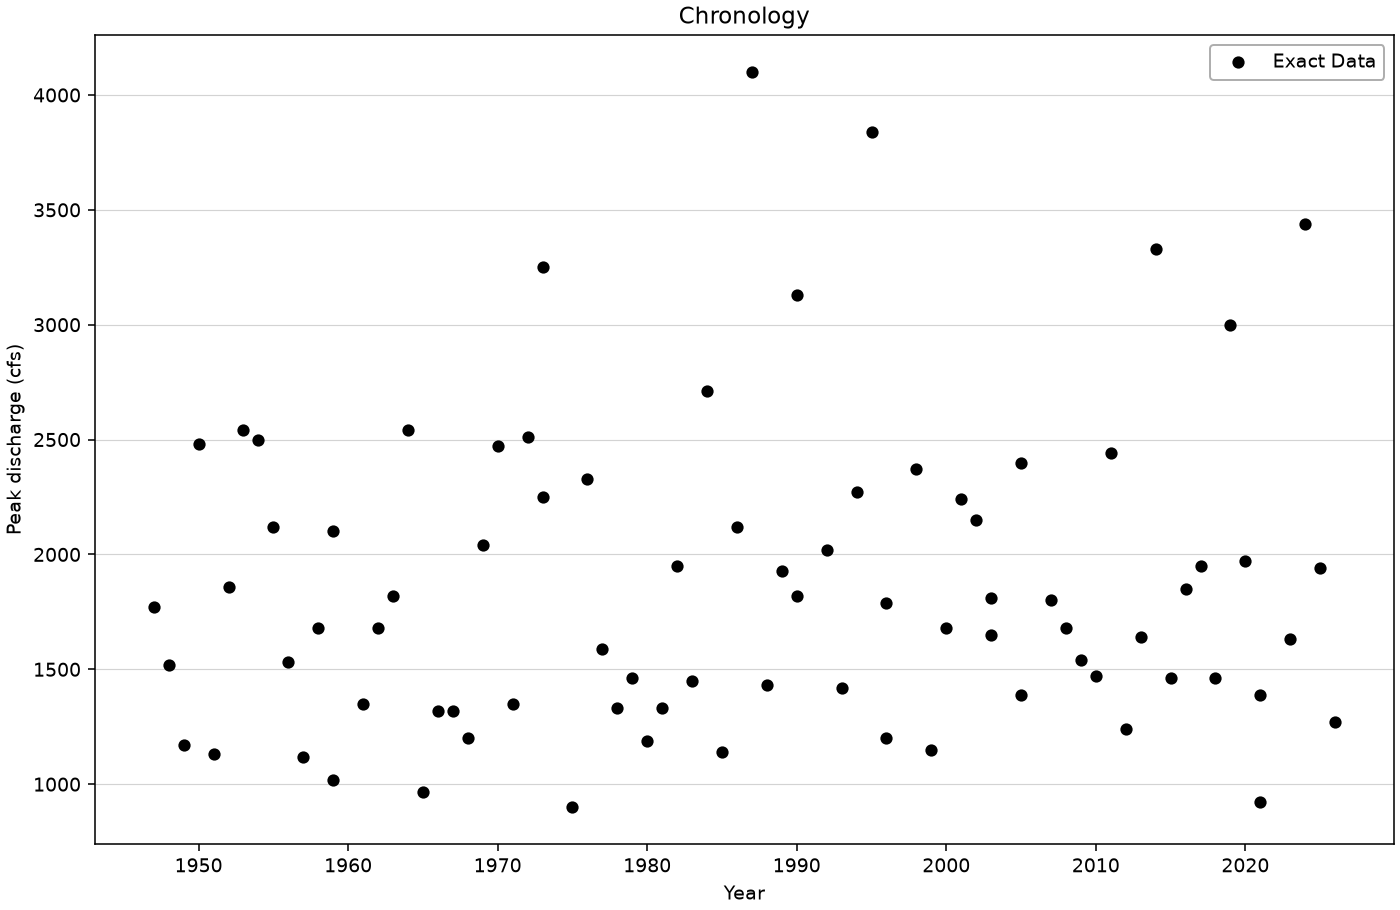

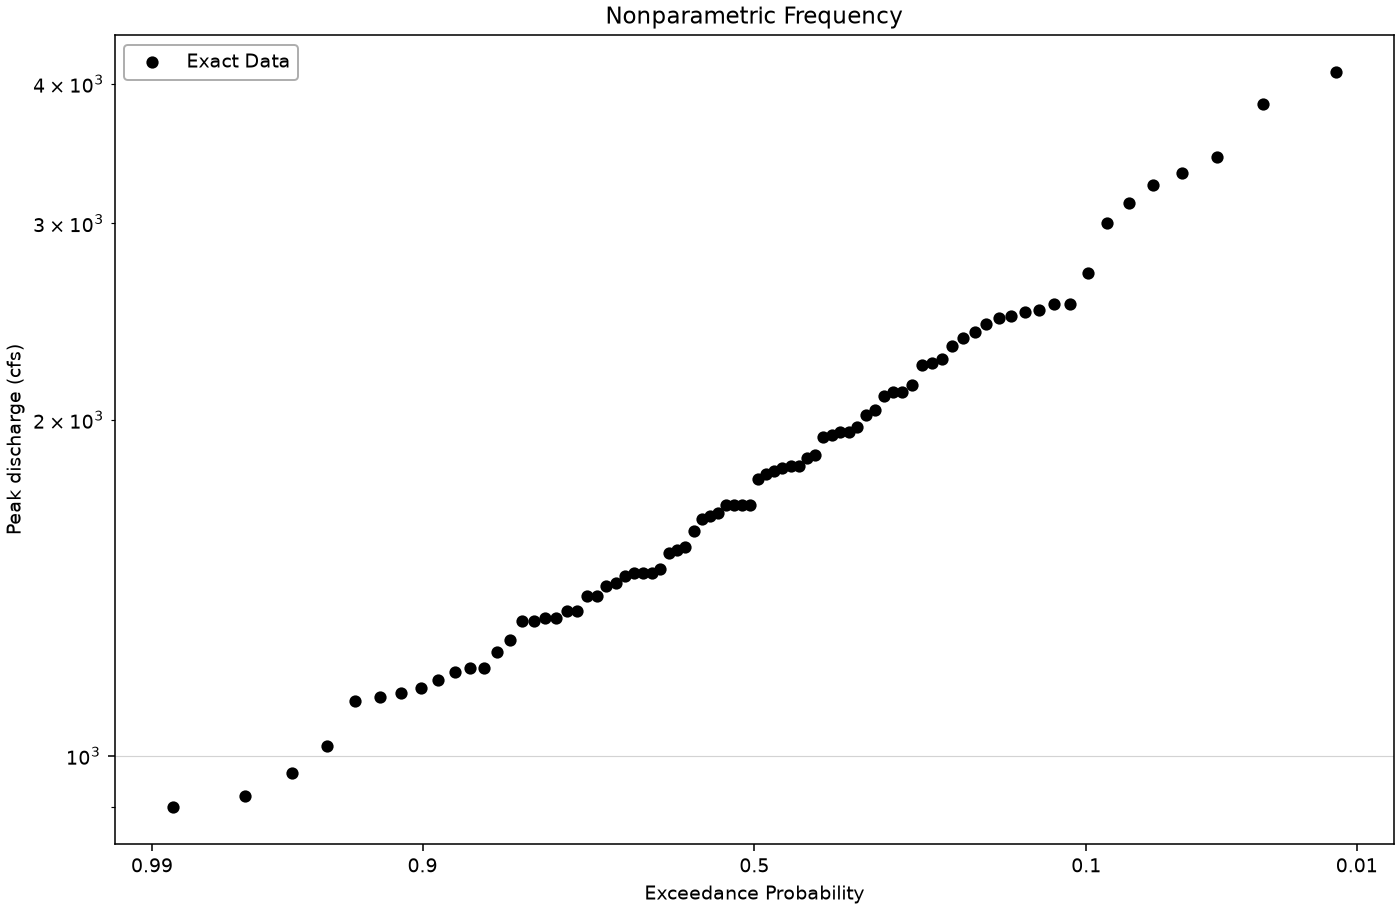

In [3]:
raw = load_raw("usgs-block-max-example")
daily = TimeSeries(TimeInterval.OneDay)
for row in raw["series"]["USGS - 01134500 - Daily Discharge"]["records"]:
    daily.Add(SeriesOrdinate[DateTime, Double](DateTime.Parse(row["Index"]), float(row["Value"])))
calendar_year, water_year = DataFrame(), DataFrame()
no_smoothing = getattr(SmoothingFunctionType, "None")  # 'None' is a Python keyword.
calendar_year.CreateBlockSeries(daily, TimeBlockWindow.CalendarYear, BlockFunctionType.Maximum,
                               no_smoothing, 10, 9, 1)
water_year.CreateBlockSeries(daily, TimeBlockWindow.WaterYear, BlockFunctionType.Maximum,
                            no_smoothing, 10, 9, 1)
calendar_year.CalculatePlottingPositions()
water_year.CalculatePlottingPositions()
assert calendar_year.ExactSeries.Count == water_year.ExactSeries.Count == 80
# Check extraction against the source's observed annual values, never fitted results.
for label, frame in [("Calendar Year", calendar_year), ("Water Year", water_year)]:
    expected = raw["inputs"]["USGS - 01134500 - Block Max - " + label]["series"]["ExactSeries"]
    np.testing.assert_array_equal([float(p.Value) for p in frame.ExactSeries], [float(r["Value"]) for r in expected])
source = {"kind": "rerun", "id": "Moose River water-year maxima", "runId": "raw:" + raw["source"]["sha256"]}
water_plots = input_data_plots(water_year, source, "Peak discharge (cfs)", "Year")
show(water_plots["chronology"])
show(water_plots["frequency"])

## Peaks over threshold and calculated diagnostics

Big Bear GHCN precipitation uses a 1-inch threshold and retains 233 peaks over 67 observation years.
Five time steps separate events; the saved period is 2 with no smoothing. These are explicit choices,
not defaults inferred from the extracted peaks. Exposure includes years with no retained events.
Mean residual life and GPD stability help examine a threshold; they do not automatically select it
or establish independence. The diagnostics below are computed by BestFit, then passed to the plot adapter.

,Events,Observation years,Events/year,Threshold (in)
0,233,67.0,3.477612,1.0


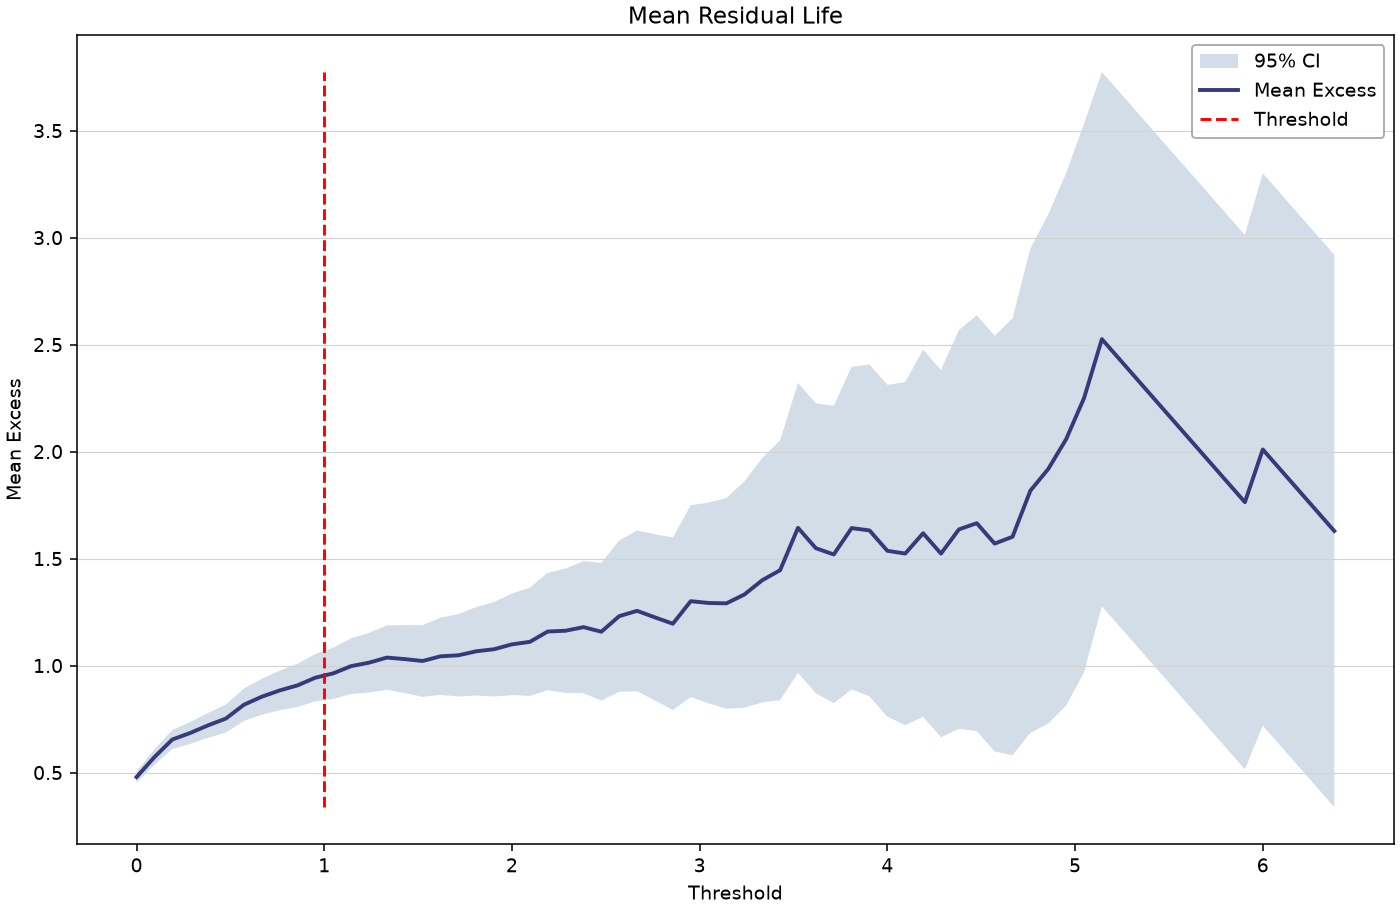

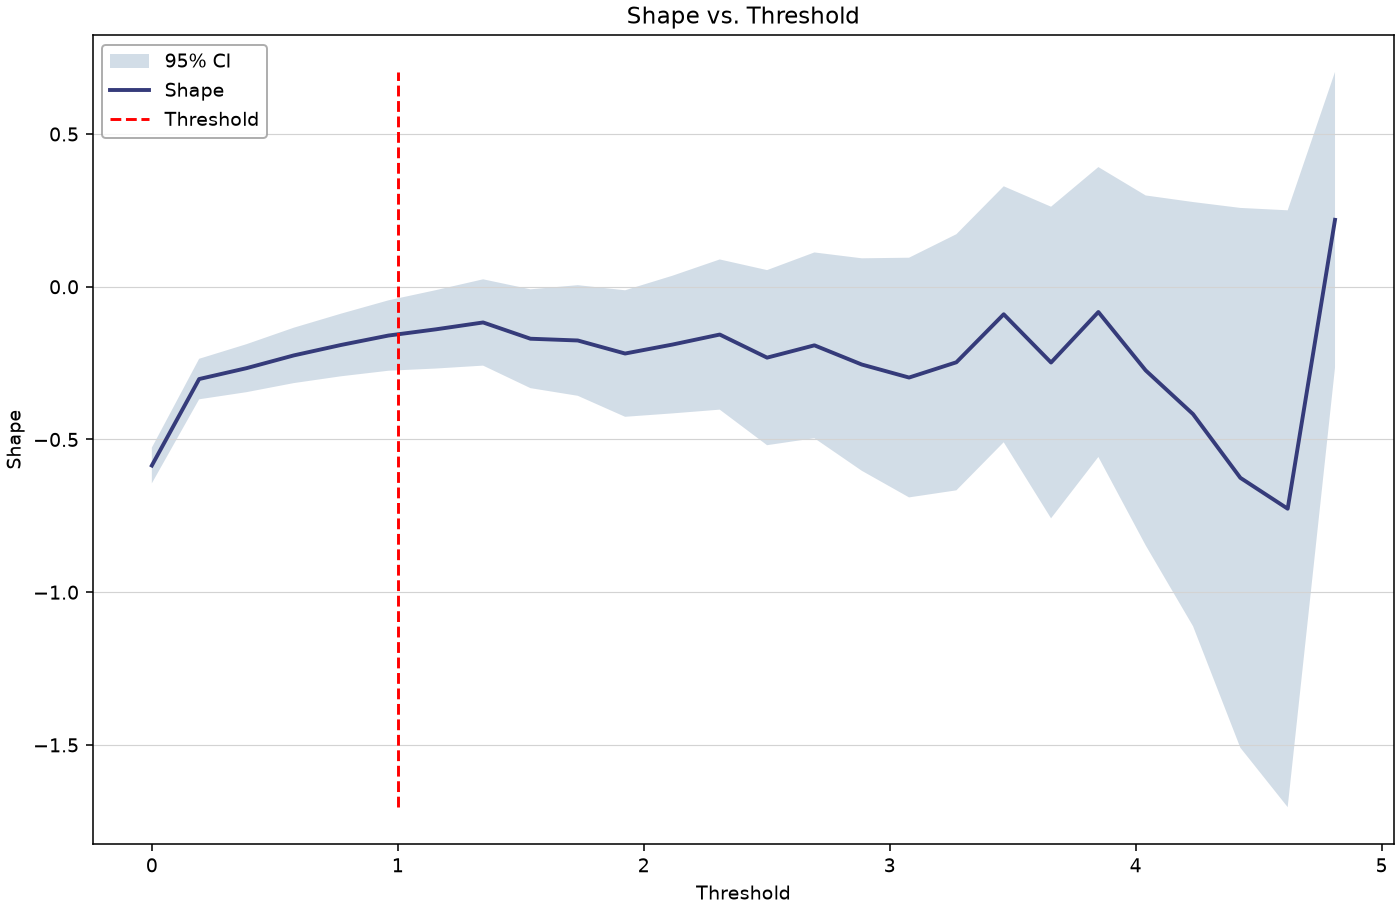

In [4]:
pot_raw = load_raw("ghcn-peaks-over-threshold-example")
precipitation = TimeSeries(TimeInterval.OneDay)
for row in pot_raw["series"]["GHCN-USC00040741-Precipitation"]["records"]:
    precipitation.Add(SeriesOrdinate[DateTime, Double](DateTime.Parse(row["Index"]), float(row["Value"])))
pot = DataFrame()
threshold, separation, period = 1.0, 5, 2
pot.CreatePeaksOverThresholdSeries(precipitation, threshold, separation, no_smoothing, period)
pot.CalculatePlottingPositions()
assert pot.ExactSeries.Count == 233 and pot.PointProcessObservationYears == 67
assert abs(pot.Lambda - 233 / 67) < 1e-14
display(pd.DataFrame([{"Events": pot.ExactSeries.Count, "Observation years": pot.PointProcessObservationYears,
                       "Events/year": pot.Lambda, "Threshold (in)": threshold}]))
values = sorted(float(p.Value) for p in precipitation.SmoothedSeries(no_smoothing, period)
                if np.isfinite(float(p.Value)))
observations = Array[Double](values)
mrl = ThresholdDiagnostics.ComputeMeanResidualLife(observations, values[len(values)//2], values[-1])
stability = ThresholdDiagnostics.ComputeParameterStability(observations, values[len(values)//2], values[-1])
pot_source = {"kind": "rerun", "id": "Big Bear POT", "runId": "raw:" + pot_raw["source"]["sha256"]}
diagnostic_figures = threshold_plots(precipitation, pot_source, no_smoothing, period, threshold, results=(mrl, stability))
show(diagnostic_figures["mean_residual_life"])
show(diagnostic_figures["shape"])

## Exact observations, historical intervals and perception thresholds

These are different likelihood contributions. A threshold window describes what would have been noticed;
its duration is information, not a fabricated sequence of annual floods. Viglione's temporal-expansion
input adds three interval floods and a perception window to the 51 exact annual observations.
The newer USGS annual-peak download covers a different period from the original Bulletin 17C data in notebook 05.

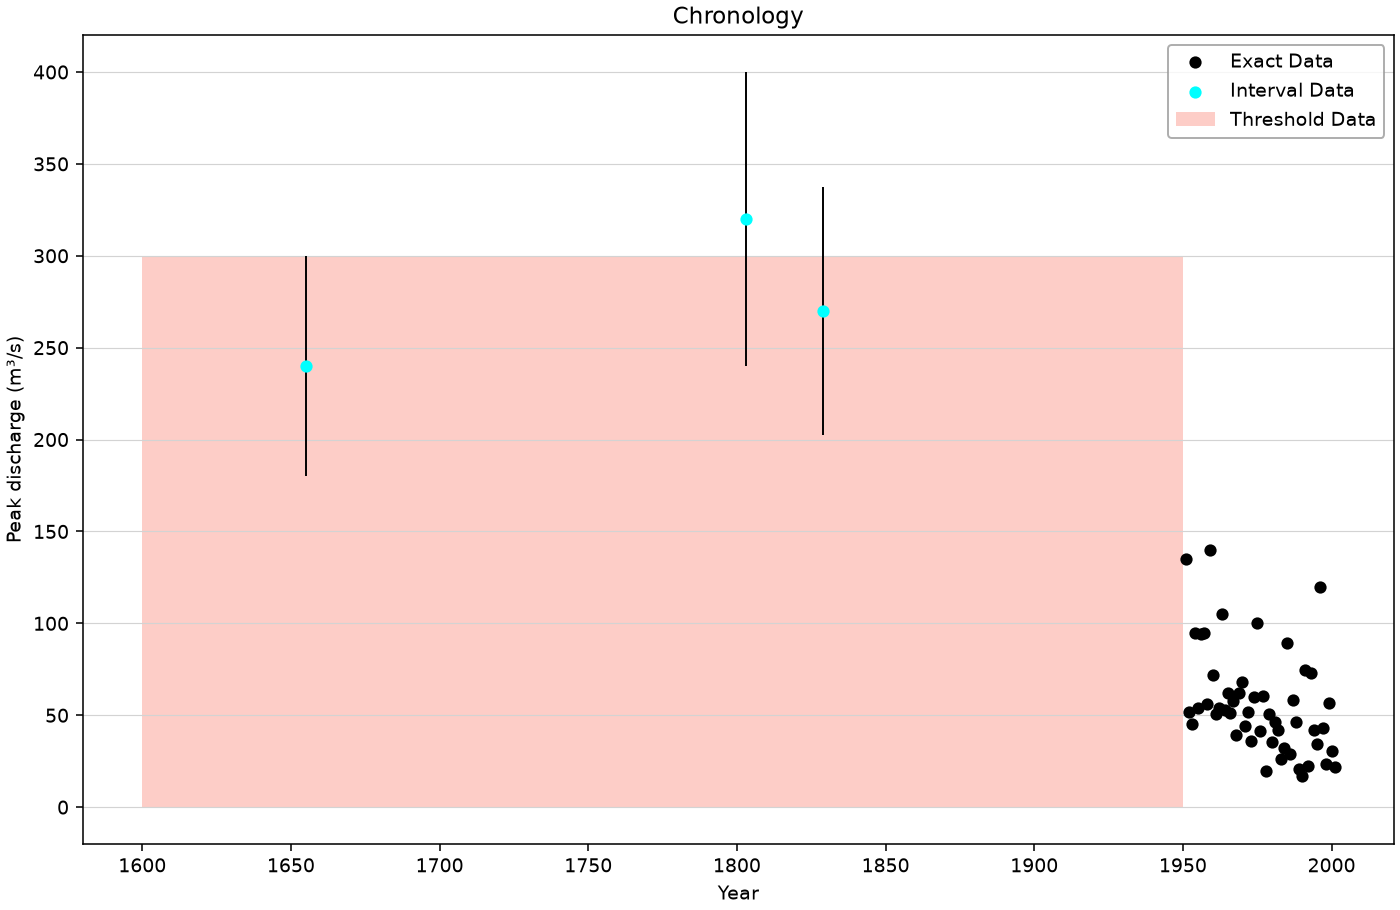

,Input,Exact observations,Unit
0,USGS - 01134500 - Peak Discharge,79,Value
1,USGS - 11274500 - Peak Discharge,94,Value


In [5]:
historical_raw = load_raw("viglione-et-al-2013")
historical_input = historical_raw["inputs"]["Systematic (1951-2001) + Temporal Expansion"]
historical = DataFrame()
for row in historical_input["series"]["ExactSeries"]:
    historical.ExactSeries.Add(ExactData(int(row["Index"]), float(row["Value"])))
for row in historical_input["series"]["IntervalSeries"]:
    historical.IntervalSeries.Add(IntervalData(int(row["Index"]), float(row["LowerValue"]),
                                              float(row["Value"]), float(row["UpperValue"])))
for row in historical_input["series"]["ThresholdSeries"]:
    window = ThresholdData(int(row["StartIndex"]), int(row["EndIndex"]), float(row["Value"]))
    window.NumberAbove = int(row["NumberAbove"])
    historical.ThresholdSeries.Add(window)
historical.PlottingParameter = 0.0
historical.CalculatePlottingPositions()
assert historical.ExactSeries.Count == 51 and historical.IntervalSeries.Count == 3
historical_source = {"kind": "rerun", "id": "Viglione temporal expansion", "runId": "raw:" + historical_raw["source"]["sha256"]}
show(input_data_plots(historical, historical_source, "Peak discharge (m³/s)", "Year")["chronology"])
recent_peaks = load_raw("usgs-peak-download-example")
display(pd.DataFrame([{"Input": name, "Exact observations": len(item["series"]["ExactSeries"]),
                       "Unit": item["metadata"]["UnitLabel"]} for name, item in recent_peaks["inputs"].items()]))

## Authentic uncertain observations: Sinnemahoning MOVE.3

The `With Errors` input contains 79 exact observations and 25 uncertain observations.
Each uncertain year carries its original LogNormal measurement distribution, not an exact point.
The explicit `LogNormal(mu, sigma)` below uses parameters in base-10 log space.
These distributions describe measurement uncertainty; they are not priors on model parameters.

,Year,Log10 mu,Log10 sigma
0,1914,4.147,0.074
1,1915,4.042,0.074
2,1916,4.289,0.074
3,1917,4.385,0.074
4,1918,4.367,0.074


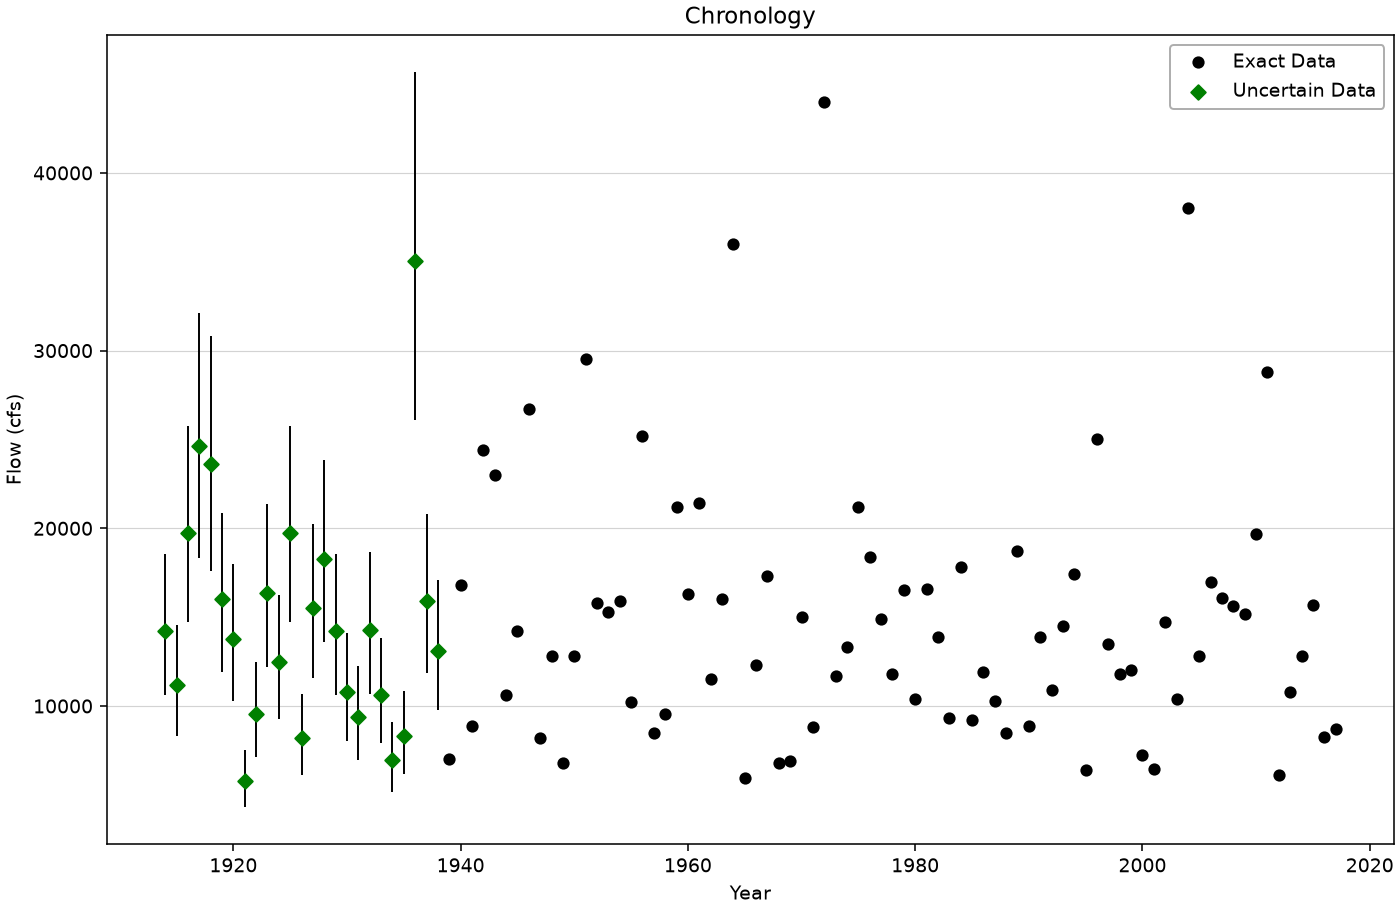

Input preparation and diagnostics: 6.24 s


In [6]:
uncertain_raw = load_raw("sinnemahoning-move3-bayesian")
uncertain_input = uncertain_raw["inputs"]["Sinnemahoning - MOVE.3 - With Errors"]
measurement = DataFrame()
for row in uncertain_input["series"]["ExactSeries"]:
    point = ExactData(DateTime.Parse(row["DateTime"]), float(row["Value"]))
    point.Index = int(row["Index"])
    point.IsLowOutlier = row.get("IsLowOutlier", "False") == "True"
    measurement.ExactSeries.Add(point)
uncertainty_table = []
for row in uncertain_input["series"]["UncertainSeries"]:
    distribution = row["children"][0]
    assert distribution["Type"] == "LogNormal"
    mu, sigma = float(distribution["Mu"]), float(distribution["Sigma"])
    measurement.UncertainSeries.Add(UncertainData(int(row["Index"]), LogNormal(mu, sigma), 0.0))
    uncertainty_table.append({"Year": int(row["Index"]), "Log10 mu": mu, "Log10 sigma": sigma})
measurement.PlottingParameter = float(uncertain_input["attributes"]["PlottingParameter"])
measurement.CalculatePlottingPositions()
assert measurement.ExactSeries.Count == 79 and measurement.UncertainSeries.Count == 25
display(pd.DataFrame(uncertainty_table).head())
measurement_source = {"kind": "rerun", "id": "Sinnemahoning With Errors", "runId": "raw:" + uncertain_raw["source"]["sha256"]}
show(input_data_plots(measurement, measurement_source, uncertain_input["metadata"]["UnitLabel"], "Year")["chronology"])
print(f"Input preparation and diagnostics: {perf_counter() - started:.2f} s")

**Adapt this example:** replace raw measurements, choose block boundaries or a defensible POT threshold,
and enter only historical or uncertain information supported by your study. Construct a `DataFrame`,
calculate its plotting positions, then pass it directly into the model constructors in notebooks 02–08.
Data preparation checks do not establish a model's fit, convergence or scientific acceptance.